In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter, MultipleLocator
import json
import pickle

from scipy.interpolate import UnivariateSpline
from datetime import datetime, timedelta
from matplotlib.dates import MinuteLocator, date2num, DateFormatter
from scipy.optimize import curve_fit
import odrpack

### Stress--Strain Curves

In [2]:
# RUN CELL---load in data
with open("AllHoustontestingdata_May2026_v20260506.pkl", "rb") as file:
    datacontainers = pickle.load(file)

In [ ]:
## Code for creating new AllHoustontestingdata file (diameters) TEST 2

# data from extraction pipeline
with open('test2_diams_all-z.pkl', 'rb') as f:  # THIS IS TEST 2!!!
    diams_dict = pickle.load(f)

# Convert timestamps, handling '0' placeholders
# Replace '0' with None, then convert to datetime with error handling
timestamps_series = pd.Series(diams_dict['Timestamps'])
timestamps_series = timestamps_series.replace('0', None)

# Convert to datetime, coercing errors to NaT (Not a Time)
diams_dict['Timestamps'] = pd.to_datetime(timestamps_series, errors='coerce')

# Ensure timestamps are in correct format
diams_dict['Timestamps'] = pd.DatetimeIndex(diams_dict['Timestamps']).as_unit('ns')

print(f"✓ Converted timestamps")
print(f"✓ Number of NaT (invalid) timestamps: {diams_dict['Timestamps'].isna().sum()}")

# Create the new diameter dictionary with all required keys
new_diameter_dict = {
    'timestamps': diams_dict['Timestamps'],
    '2d_diameters_cm': diams_dict['diameters_cm'],
    'zlevels_cm': diams_dict['z_levels_cm'],
    '2d_diameters_raw': diams_dict['diameters'],  # pixel diameters
    'zlevels_pixels': diams_dict['z_levels']  # pixel z-levels
}

# Optional: Add filename if you want
# new_diameter_dict['filename'] = 'your_new_data_filename.csv'

# Replace the entire dictionary
datacontainers['datacontainer_test2_diameters'] = new_diameter_dict  # THIS IS TEST 2!!!

# Verify the transfer
print("✓ Keys in new dict:", list(new_diameter_dict.keys()))
print("✓ Timestamps count:", len(new_diameter_dict['timestamps']))
print("✓ Timestamp dtype:", new_diameter_dict['timestamps'].dtype)
print("✓ Number of z-levels:", len(new_diameter_dict['2d_diameters_cm']))
print("✓ Each diameter array shape:", new_diameter_dict['2d_diameters_cm'][0].shape)
print("✓ Z-levels (cm) count:", len(new_diameter_dict['zlevels_cm']))
print("✓ Z-levels (pixels) count:", len(new_diameter_dict['zlevels_pixels']))

# Save the updated pickle file
with open('AllHoustontestingdata_May2026_v20260506.pkl', 'wb') as f:
    pickle.dump(datacontainers, f)

print("\n✓✓✓ Transfer complete! Updated pickle saved as 'AllHoustontestingdata_May2026_v20260506.pkl'")

In [5]:
# RUN CELL---interpolation and plotting functions (preprocessing)
#Perform spline interpolation
def spline_interpolate(time, data):
    # Convert datetime to float days for spline interpolation
    time_float = date2num(time)
    spline = UnivariateSpline(time_float, data, s=0)  # s=0 means no smoothing
    return spline, time_float

# Plot the data
def plot_pressure_data(time, pressure):
    fig = plt.figure(figsize=(20, 12))
    ax = fig.add_subplot(111)    
    plt.plot(time, pressure, 'o', label='Pressure Data Collected on 07262024')
    #plt.plot(time, spline(time_float), '-', label='Spline Interpolation')
    
    fig.text(0.5, 0.5, "Preliminary - \n Internal LEGEND Result",
             fontsize=75, color="red",
             ha="center", va="center", alpha=0.30,
             rotation=25)      
    plt.title('Reentrant Tube LoFi Pressure Test July 2024')
    ax.tick_params(axis='y',labelsize=20)   
    ax.tick_params(axis='x',labelsize=10)       
    ax.set_ylabel('Pressure (PSI)',fontsize=40) 
    ax.set_xlabel('Timestamp',fontsize=30)     
    
    # Format the x-axis with appropriate locators and formatters
    plt.gca().xaxis.set_major_locator(MinuteLocator(interval=5))
    plt.gca().xaxis.set_minor_locator(MinuteLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(DateFormatter("%Y-%m-%d %H:%M:%S"))
    
    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()  # Rotate and format the x-axis labels
    plt.show()
    
def plot_strain_data(time, strain):
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    plt.plot(time, strain, 'o', label='Original Data')
    #plt.plot(time, spline(time_float), '-', label='Spline Interpolation')
    
    fig.text(0.5, 0.5, "Preliminary - \n Internal LEGEND Result",
             fontsize=75, color="red",
             ha="center", va="center", alpha=0.30,
             rotation=25)    
    
    plt.xlabel('Time')
    plt.ylabel('Strain (dless)')
    plt.title('Houston LoFi Pressure Test 07262024')
    
    ax.tick_params(axis='y',labelsize=20)   
    ax.tick_params(axis='x',labelsize=20) 
    
    # Format the x-axis with appropriate locators and formatters
    plt.gca().xaxis.set_major_locator(MinuteLocator(interval=5))
    plt.gca().xaxis.set_minor_locator(MinuteLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(DateFormatter("%Y-%m-%d %H:%M:%S"))
    
    plt.legend()
    plt.grid(True)
    plt.gcf().autofmt_xdate()  # Rotate and format the x-axis labels
    plt.show() 
    
def plot_pressurestrainplot(x, y, t, 
                           xlabel='Pressure (psi)', ylabel='Strain (arb units)',plottitle="Plot Title",
                           cbar_label='Time Since Start (s)', figsize=(8, 6)):
    """
    Plots x/y data points color-coded by a third variable t.

    Parameters:
        x (list or array): X-axis values.
        y (list or array): Y-axis values.
        t (list or array): Values for color-coding.
        xlabel (str, optional): Label for the X-axis. Defaults to 'X-axis'.
        ylabel (str, optional): Label for the Y-axis. Defaults to 'Y-axis'.
        cbar_label (str, optional): Label for the color bar. Defaults to 'T'.
        figsize (tuple, optional): Figure size. Defaults to (8, 6).

    Returns:
        None
    """
    plt.figure(figsize=figsize)
    plt.title(plottitle, fontsize=16)
    scatter = plt.scatter(x[::10], y[::10], c=t[::10], cmap='viridis', edgecolor='k',s=100)
    plt.colorbar(scatter, label=cbar_label)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(plottitle)
    plt.grid(True)
    plt.show()


def plot_data_grid(datasets, bursttimes, titles=None, xlabel='Timestamps', ylabel='Pressure (PSI)', 
                   figsize=(10, 8), overall_title="Test"):
    """
    Plots four x/y datasets as a 2x2 grid using Matplotlib and adds corresponding burst times.

    Parameters:
        datasets (list of tuples): A list of four (x, y) datasets. Each dataset is a tuple (x, y).
        bursttimes (list): List of 4 datetime objects (or x-values) for burst times.
        titles (list of str, optional): Titles for each subplot. Defaults to None.
        xlabel (str, optional): Label for the X-axis.
        ylabel (str, optional): Label for the Y-axis.
        figsize (tuple, optional): Figure size.
        overall_title (str, optional): Suptitle for the grid.

    Returns:
        None
    """
    if len(datasets) != 4:
        raise ValueError("Exactly 4 datasets are required.")
    if len(bursttimes) != 4:
        raise ValueError("Exactly 4 burst times are required.")

    if titles is None:
        titles = [f"Plot {i+1}" for i in range(4)]
    if len(titles) != 4:
        raise ValueError("Exactly 4 titles are required.")

    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)

    for i, ax in enumerate(axes.flat):
        x, y = datasets[i]
        ax.plot(x, y, marker='o', linestyle='-', label="Raw Data")

        # Add burst time as vertical line
        ax.axvline(bursttimes[i], color='red', linestyle='--', label='Burst Time')

        # Annotate burst time text
        #ax.text(bursttimes[i], max(y), f"Burst\n{bursttimes[i].strftime('%H:%M:%S')}",
        #        color='red', ha='left', va='bottom', fontsize=8, rotation=90)

        ax.set_title(titles[i])
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True)

        # Format x-axis
        ax.xaxis.set_major_formatter(DateFormatter("%H:%M:%S"))
        ax.xaxis.set_major_locator(MinuteLocator(interval=10))
        ax.xaxis.set_minor_locator(MinuteLocator(interval=5))

        ax.legend()

    fig.suptitle(overall_title, fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.15)
    plt.show()

In [12]:
# RUN CELL---plotdeformationdata_specific (linear fits)
def get_uncertainties_at_stress(target_stress, stress_arr, strain_arr, 
                                  sigma_stress_arr, sigma_strain_arr,
                                  tolerance=0.5):
    """
    Interpolate strain, stress, and their uncertainties at a target stress value.
    
    Parameters:
    - target_stress:    desired hoop stress value (MPa)
    - tolerance:        if an exact match is within this many MPa, use it directly
    """
    stress_arr = np.array(stress_arr)
    strain_arr = np.array(strain_arr)
    sigma_stress_arr = np.array(sigma_stress_arr)
    sigma_strain_arr = np.array(sigma_strain_arr)
    
    # Check if any point is close enough to use directly
    diffs = np.abs(stress_arr - target_stress)
    nearest_idx = np.argmin(diffs)
    
    if diffs[nearest_idx] < tolerance:
        # Close enough — use directly
        print(f"  Using nearest data point (Δσ = {diffs[nearest_idx]:.4f} MPa)")
        return {
            'stress':        stress_arr[nearest_idx],
            'strain':        strain_arr[nearest_idx],
            'sigma_stress':  sigma_stress_arr[nearest_idx],
            'sigma_strain':  sigma_strain_arr[nearest_idx],
            'interpolated':  False
        }
    
    # Find bracketing points (where stress crosses target_stress)
    diff = stress_arr - target_stress
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    
    if len(sign_changes) == 0:
        print(f"WARNING: target stress {target_stress} MPa not found in data range "
              f"({stress_arr.min():.2f} – {stress_arr.max():.2f} MPa)")
        return None
    
    idx = sign_changes[0]
    s_lo, s_hi = stress_arr[idx], stress_arr[idx + 1]
    e_lo, e_hi = strain_arr[idx], strain_arr[idx + 1]
    ss_lo, ss_hi = sigma_stress_arr[idx], sigma_stress_arr[idx + 1]
    se_lo, se_hi = sigma_strain_arr[idx], sigma_strain_arr[idx + 1]
    
    # Linear interpolation weight
    t = (target_stress - s_lo) / (s_hi - s_lo)
    
    interp_strain       = e_lo  + t * (e_hi  - e_lo)
    interp_sigma_stress = ss_lo + t * (ss_hi - ss_lo)
    interp_sigma_strain = se_lo + t * (se_hi - se_lo)
    
    return {
        'stress':        target_stress,
        'strain':        interp_strain,
        'sigma_stress':  interp_sigma_stress,
        'sigma_strain':  interp_sigma_strain,
        'interpolated':  True,
        'bracket':       (s_lo, s_hi)
    }
    
def calculate_yield_with_errors_mixed_fits(params_region1, covariance1, params_region2, covariance2):
    """
    Calculate yield point and yield strength with uncertainties.
    
    IMPORTANT: This version handles mixed fit orientations:
    - Fit 1 (params_region1): strain = a1*stress + b1 (needs inversion)
    - Fit 2 (params_region2): stress = a2*strain + b2 (already correct form)
    
    Returns yield point (strain) and yield strength (stress) at intersection.
    """
    # Fit 1 parameters (backward form: ε = a1*σ + b1)
    a1_backward, b1_backward = params_region1
    sigma_a1_backward, sigma_b1_backward = np.sqrt(np.diag(covariance1))
    
    # Invert Fit 1 to get: σ = (1/a1)*ε - (b1/a1)
    a1 = 1 / a1_backward  # slope in forward form
    b1 = -b1_backward / a1_backward  # intercept in forward form
    
    # Error propagation for inverted parameters
    # For a1 = 1/a1_backward:
    sigma_a1 = sigma_a1_backward / (a1_backward**2)
    
    # For b1 = -b1_backward/a1_backward:
    # Using δf = sqrt((∂f/∂x)²σ_x² + (∂f/∂y)²σ_y²)
    db1_da1_backward = b1_backward / (a1_backward**2)
    db1_db1_backward = -1 / a1_backward
    sigma_b1 = np.sqrt(
        (db1_da1_backward * sigma_a1_backward)**2 +
        (db1_db1_backward * sigma_b1_backward)**2
    )
    
    # Fit 2 parameters (already in correct form: σ = a2*ε + b2)
    a2, b2 = params_region2
    sigma_a2, sigma_b2 = np.sqrt(np.diag(covariance2))
    
    # Now both fits are in form: σ = a*ε + b
    # Calculate intersection
    
    # YIELD POINT (strain at intersection)
    yield_point = (b2 - b1) / (a1 - a2)
    
    # Error propagation for yield point
    d_epsilon_da1 = -(b2 - b1) / (a1 - a2)**2
    d_epsilon_db1 = -1 / (a1 - a2)
    d_epsilon_da2 = (b2 - b1) / (a1 - a2)**2
    d_epsilon_db2 = 1 / (a1 - a2)
    
    yield_point_error = np.sqrt(
        (d_epsilon_da1 * sigma_a1)**2 +
        (d_epsilon_db1 * sigma_b1)**2 +
        (d_epsilon_da2 * sigma_a2)**2 +
        (d_epsilon_db2 * sigma_b2)**2
    )
    
    # YIELD STRENGTH (stress at intersection)
    yield_strength = a1 * yield_point + b1
    
    # Error propagation for yield strength
    d_sigma_da1 = yield_point
    d_sigma_db1 = 1
    d_sigma_d_epsilon = a1
    
    yield_strength_error = np.sqrt(
        (d_sigma_da1 * sigma_a1)**2 +
        (d_sigma_db1 * sigma_b1)**2 +
        (d_sigma_d_epsilon * yield_point_error)**2
    )
    
    # Verification using fit 2
    yield_strength_check = a2 * yield_point + b2
    
    return {
        'yield_point': yield_point,
        'yield_point_error': yield_point_error,
        'yield_strength': yield_strength,
        'yield_strength_error': yield_strength_error,
        'yield_strength_check': yield_strength_check
    }, sigma_a1_backward, sigma_b1_backward

def linearfit(x, a, b):
    return a * x + b

def sqrtfit(x, a, b,c):
    return a * np.sqrt(x-b) + c  

def fitlinearregion_xmask(deformdata_plottingtemp,hoopstressdata_plottingtemp,xmin,xmax):
    x_array = np.array(deformdata_plottingtemp)
    y_array = np.array(hoopstressdata_plottingtemp)
    mask = ((x_array >= xmin) & (x_array <= xmax))
    x_fit = x_array[mask]
    y_fit = y_array[mask]
    # Perform the fit
    params, covariance = curve_fit(linearfit, x_fit, y_fit)
    return params, covariance

def fitlinearregion_multiwindow(x_data, y_data, windows):
    """
    Fit a linear model to data from multiple non-contiguous windows.
    
    Parameters:
    - x_data: array of x values
    - y_data: array of y values  
    - windows: list of (xmin, xmax) tuples defining the regions to include
    
    Returns:
    - params: (slope, intercept)
    - covariance: covariance matrix
    """
    x_array = np.array(x_data)
    y_array = np.array(y_data)
    
    # Create a combined mask for all windows
    combined_mask = np.zeros(len(x_array), dtype=bool)
    
    for xmin, xmax in windows:
        window_mask = (x_array >= xmin) & (x_array <= xmax)
        combined_mask = combined_mask | window_mask  # OR operation to combine
    
    # Extract data points from all windows
    x_fit = x_array[combined_mask]
    y_fit = y_array[combined_mask]
    
    # Perform the fit on combined data
    params, covariance = curve_fit(linearfit, x_fit, y_fit)
        
    return params, covariance

# this takes in both x/strain and y/stress errors
# note that these are the flipped fit errors, so we're fitting strain therefore x = stress, y = strain
def fitlinearregion_multiwindow_odr(x_data, y_data, windows, 
                                     sx_data, sy_data):
    """
    Fit a linear model using ODR to account for errors on both axes.

    NOTE ON ORIENTATION:
    Fit1 is fitted in the BACKWARD orientation: ε = a·σ + b
    This means:
        x_data = stress (σ)  — the independent variable in the fit
        y_data = strain (ε)  — the dependent variable in the fit
    This is the OPPOSITE of the plot, where strain is on the x-axis.
    
    Parameters:
    - x_data:      array of x values (stress, in backward orientation)
    - y_data:      array of y values (strain)
    - windows:     list of (xmin, xmax) tuples (stress-based windows)
    - sx_data:     point-by-point uncertainty on x (stress)
    - sy_data:     scalar or array uncertainty on y (strain)
    
    Returns:
    - beta:        (slope, intercept) in same orientation as before: ε = a*σ + b
    - cov_beta:    covariance matrix of (slope, intercept)
    """
    x_array = np.array(x_data)
    y_array = np.array(y_data)
    sx_array = np.array(sx_data)
    sy_array = np.array(sy_data)
    
    # Build combined mask
    combined_mask = np.zeros(len(x_array), dtype=bool)
    for xmin, xmax in windows:
        combined_mask = combined_mask | ((x_array >= xmin) & (x_array <= xmax))
    
    x_fit  = x_array[combined_mask]
    y_fit  = y_array[combined_mask]
    sx_fit = sx_array[combined_mask]
    sy_fit = sy_array[combined_mask]
    
    # Convert std devs to weights: w = 1/sigma^2
    weight_x = 1.0 / sx_fit**2
    weight_y = 1.0 / sy_fit**2
    
    output = odrpack.odr_fit(
        lambda x, beta: beta[0] * x + beta[1],  # note: x first, then beta in lambda statement
        x_fit,
        y_fit,
        beta0=np.array([1.0, 0.0]),  # initial guess as 1 / slope [MPa], - intercept / slope
        weight_x=weight_x,
        weight_y=weight_y
    )
    
    print(f"ODR Fit1: ε = {output.beta[0]:.6f}·σ + {output.beta[1]:.6f}")  # slope, intercept
    print(f"ODR residual variance: {output.res_var:.4f}")
    
    cov_absolute = output.cov_beta / output.res_var
    
    return output.beta, output.cov_beta

def plotdeformationdata_specific(datacontainer_deformationdata, alldatacontainers, test_number=1, target_zlevel_pixels=1100):
    # Get the right data container and settings based on test number
    test_key = f'datacontainer_test{test_number}'
    
    if test_number == 1:
        # Define TWO windows for Fit 1 (stress-based)
        region1_ywindows = [(0, 180)]  # List of tuples
        region2_xwindow = [0.008, 0.025] 
        target_timestamp = pd.Timestamp("2024-07-26 14:22:04.5")
    elif test_number == 2:
        region1_ywindows = [(0, 180)]  # List of tuples
        region2_xwindow = [0.008, 0.025]
        target_timestamp = pd.Timestamp("2024-08-29 14:10:04.5")
    
    time_float = date2num(alldatacontainers[test_key]['timestamps'])
    pressureinterpol = UnivariateSpline(time_float, alldatacontainers[test_key]['pressure_psi'], s=0)

    timestamps_array = np.array(datacontainer_deformationdata['timestamps_uniform'])
    closest_timestampindex = np.argmin(np.abs(timestamps_array.astype('datetime64[ns]') - target_timestamp.to_datetime64()))

    temp = date2num(target_timestamp)
    deformdata_plottingtemp = []
    pressuredata_plottingtemp = []
    hoopstressdata_plottingtemp = []
    wallthickness_mm = 1.5
    i = 0
    for indytimestamp in datacontainer_deformationdata['timestamps_uniform']:
        temptime = date2num(indytimestamp)
        tempdata = datacontainer_deformationdata['maxdeform_smoothed_percent_interpol'](temptime)
        deformdata_plottingtemp.append(float(tempdata))
        pressuredata_plottingtemp.append(pressureinterpol(temptime))
        maxdeform_mm = (10*datacontainer_deformationdata['maxdeform_cm'][i])
        pressure_MPA = pressureinterpol(temptime)/145.03773773  # convert to MPa
        temphoopstress = (pressure_MPA*maxdeform_mm)/(2*wallthickness_mm)
        hoopstressdata_plottingtemp.append(temphoopstress)
        i = i + 1

    datacontainer_deformationdata['hoopstress_MPa'] = hoopstressdata_plottingtemp

    ### FOR ODR ###
    # Point-by-point stress uncertainty (x-axis, since Fit1 has stress on x)
    sigma_diameter_cm = 0.03176297829408378 # measurement error for z-level
    sigma_d0_cm = 0.127        # uncertainty on d0 (cm)
    sigma_d_mm = sigma_diameter_cm * 10  # measurement error in mm
    pressure_arr_MPa = np.array(pressuredata_plottingtemp) / 145.03773773 # convert to MPa
    sigma_stress_pointwise = (pressure_arr_MPa * sigma_d_mm) / (2 * wallthickness_mm)  # PD/2t
    
    # Point-by-point strain uncertainty (y-axis)
    d0 = 15.26032  # d0 (undeformed cylinder diameter)
    diameter_arr_cm = np.array(datacontainer_deformationdata['maxdeform_cm'])

    sigma_strain_arr = np.sqrt(
        (sigma_diameter_cm / d0)**2 +
        (diameter_arr_cm * sigma_d0_cm / d0**2)**2
    )

    target = 174.69  # MPa — your desired stress value

    # return uncertainties for given hoop stress value (generally 0.2% offset YS)
    result = get_uncertainties_at_stress(
        target,
        hoopstressdata_plottingtemp,
        deformdata_plottingtemp,
        sigma_stress_pointwise,
        sigma_strain_arr
    )
    
    if result is not None:
        print(f"\n=== Uncertainties at σ = {result['stress']:.2f} MPa ===")
        print(f"  Strain:        {result['strain']:.6f}")
        print(f"  σ(strain):     {result['sigma_strain']:.6f}")
        print(f"  σ(stress):     {result['sigma_stress']:.4f} MPa")
        if result['interpolated']:
            print(f"  (interpolated between {result['bracket'][0]:.2f} and {result['bracket'][1]:.2f} MPa)")
    
    plotting_xarray = np.array(deformdata_plottingtemp)
    plotting_yarray = np.array(hoopstressdata_plottingtemp)

    params_region1, covariance_region1 = fitlinearregion_multiwindow_odr(
    hoopstressdata_plottingtemp,   # x: stress
    deformdata_plottingtemp,       # y: strain
    region1_ywindows,
    sx_data=sigma_stress_pointwise,   # stress uncertainty on x
    sy_data=sigma_strain_arr       # strain uncertainty on y
    )
    a1, b1 = params_region1
    print(f"a1 = {a1:.6f}, b1 = {b1:.6f}")
    print(f"Implied E = {1/a1:.1f} MPa")
    
    y_fit_line_region1 = linearfit(np.array(hoopstressdata_plottingtemp), a1, b1)
        
    ## Multiple masks for Region 1
    region1_mask_combined = np.zeros(len(plotting_yarray), dtype=bool)
    for ymin, ymax in region1_ywindows:
        mask = (plotting_yarray >= ymin) & (plotting_yarray <= ymax)
        region1_mask_combined = region1_mask_combined | mask

    stress_in_fit = plotting_yarray[region1_mask_combined]
    strain_in_fit = plotting_xarray[region1_mask_combined]
    
    # Model predictions at fit points (Fit1 is ε = a1*σ + b1)
    strain_predicted = a1 * stress_in_fit + b1
    
    # Residuals
    residuals = strain_in_fit - strain_predicted  # data - model
    
    # Uncertainty on strain at each point (propagate 300 µm diameter uncertainty)
    # σ_strain = σ_d / d0 ≈ 0.03 / 15.26032 ≈ 0.002 (roughly uniform)
    sigma_strain = 0.03 / d0

    params_region2, covariance_region2 = fitlinearregion_xmask(deformdata_plottingtemp, hoopstressdata_plottingtemp,
                                                        region2_xwindow[0], region2_xwindow[1])
    a2, b2 = params_region2

    # Hoop Stress/Strain plot (stress vs strain) with dynamic title
    plt.figure(figsize=(10, 6))
    plt.title(f"Hoop Stress/Strain - LoFi Test {test_number}", size=22)
    plt.ylabel(r'Hoop Stress $\sigma_\theta$ [MPa]', size='xx-large')
    plt.xlabel(r'Hoop Strain $\epsilon_\theta$ [unitless]', size='xx-large')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    
    plt.scatter(deformdata_plottingtemp, hoopstressdata_plottingtemp, marker='o', s=10, 
                label=f'LoFi Test {test_number} Data, z-level {target_zlevel_pixels}', color='#D55E00')
    plt.plot(y_fit_line_region1, np.array(hoopstressdata_plottingtemp), color="#56B4E9", 
             label=fr"""Fit: $\sigma$ = {1/a1:.2f}$\epsilon$ + {-b1/a1:.2f}""")

    plt.scatter(plotting_xarray[region1_mask_combined], plotting_yarray[region1_mask_combined], marker='x', s=10, label='Fit Elastic Region', color='#56B4E9')
    plt.xlim(-0.005, 0.12)
    plt.ylim(0, 250)

    # After you've calculated both fits
    if a1 is not None and a2 is not None:
        yield_results, sigma_a1_backward, sigma_b1_backward = calculate_yield_with_errors_mixed_fits(
            params_region1, covariance_region1,  # ε = a·σ + b (backward)
            params_region2, covariance_region2   # σ = a·ε + b (forward)
        )
        
        print(f"\n=== Yield Analysis for Test {test_number} ===")
        print(f"Yield Point (ε_y):     {yield_results['yield_point']:.4f} ± {yield_results['yield_point_error']:.4f}")
        print(f"Yield Strength (σ_y):  {yield_results['yield_strength']:.2f} ± {yield_results['yield_strength_error']:.2f} MPa")
        print(f"Params region 1: {params_region1}")
        print(f"Covariance region 1: {covariance_region1}")

    # calculate yield strength with 0.2% offset and 0.5% EUL methods
    strain_arr = np.array(deformdata_plottingtemp)
    stress_arr = np.array(hoopstressdata_plottingtemp)
    eul_min_stress_threshold = 70
    min_stress_threshold = 174  # may need adjusting depending on how noisy the elastic region is
    
    # ================================================
    # 0.5% EUL yield strength
    # ================================================
    # Find the data point closest to epsilon = 0.005
    eul_strain_target = 0.005
    # Restrict search to above stress threshold (consistent with 0.2% offset)
    eul_search_mask = stress_arr > eul_min_stress_threshold  # reuse same threshold as 0.2% offset
    
    strain_search_eul = strain_arr[eul_search_mask]
    stress_search_eul = stress_arr[eul_search_mask]
    pressure_search_eul = np.array(pressuredata_plottingtemp)[eul_search_mask]
    
    # Find nearest point to target strain within masked region
    eul_idx_masked = np.argmin(np.abs(strain_search_eul - eul_strain_target))
    eul_stress = stress_search_eul[eul_idx_masked]
    eul_strain_actual = strain_search_eul[eul_idx_masked]
    eul_pressure = pressure_search_eul[eul_idx_masked] / 145.03773773
    eul_stress_err = (eul_pressure * sigma_d_mm) / (2 * wallthickness_mm)
    
    print(f"\n=== 0.5% EUL Yield Strength ===")
    print(f"  Nearest data strain = {eul_strain_actual:.5f} (target 0.005)")
    print(f"  σ(ε≈0.005) = {eul_stress:.2f} ± {eul_stress_err:.2f} MPa")
    
    # ================================================
    # 0.2% offset yield strength
    # ================================================
    # Offset line: σ = a1_fwd * (ε - 0.002) + b1_fwd
    #                = a1_fwd * ε + (b1_fwd - 0.002 * a1_fwd)
    a1_fwd     = 1 / a1
    b1_fwd     = -b1 / a1
    b1_offset  = b1_fwd - 0.002 * a1_fwd
    
    # Evaluate offset line at every data strain value
    offset_line_at_data = a1_fwd * strain_arr + b1_offset
    
    # Find where data crosses the offset line:
    # look for sign change in (stress_data - offset_line)
    diff = stress_arr - offset_line_at_data
    
    # Restrict crossing search to above stress threshold
    search_mask = stress_arr > min_stress_threshold
    
    diff_search = diff[search_mask]
    strain_search = strain_arr[search_mask]
    stress_search = stress_arr[search_mask]
    
    sign_changes = np.where(np.diff(np.sign(diff_search)))[0]
    
    if len(sign_changes) == 0:
        print("WARNING: No intersection found above threshold.")
    else:
        idx = sign_changes[0]
        strain_lo, strain_hi = strain_search[idx], strain_search[idx + 1]
        diff_lo,   diff_hi   = diff_search[idx],   diff_search[idx + 1]
    
        # Interpolated intersection strain
        offset_strain = strain_lo - diff_lo * (strain_hi - strain_lo) / (diff_hi - diff_lo)
        # Interpolated intersection stress (from data, not fit)
        offset_stress = stress_search[idx] + (stress_search[idx+1] - stress_search[idx]) * \
                        (offset_strain - strain_lo) / (strain_hi - strain_lo)
    
        # Uncertainty at intersection point
        offset_pressure = pressuredata_plottingtemp[idx] / 145.03773773  # convert to MPa
        offset_stress_err = (offset_pressure * sigma_d_mm) / (2 * wallthickness_mm)
        print(f"  Measurement uncertainty at intersection (for reference): {offset_stress_err:.4f} MPa")
    
        # Also propagate Fit1 uncertainty into the intersection location
        sigma_a1_fwd   = sigma_a1_backward / (a1**2)  # slope uncertainty
        db1_fwd_da1    = b1 / (a1**2)
        db1_fwd_db1    = -1 / a1
        sigma_b1_fwd   = np.sqrt(
            (db1_fwd_da1 * sigma_a1_backward)**2 +
            (db1_fwd_db1 * sigma_b1_backward)**2
        )  # intercept uncertainty
        # Intersection strain uncertainty from slope/intercept of offset line
        # d(eps_intersect)/d(a1_fwd) and d(eps_intersect)/d(b1_offset) via
        # approximate local data slope at intersection
        local_data_slope = (stress_search[idx+1] - stress_search[idx]) / (strain_search[idx+1] - strain_search[idx])
        d_eps_da1 = offset_strain / (local_data_slope - a1_fwd)
        d_eps_db1 = 1 / (local_data_slope - a1_fwd)
    
        offset_strain_err = np.sqrt(
            (d_eps_da1 * sigma_a1_fwd)**2 +
            (d_eps_db1 * sigma_b1_fwd)**2
        )

        offset_stress_err_total = local_data_slope * offset_strain_err

        term_strain_b1    = (local_data_slope * d_eps_db1 * sigma_b1_fwd)**2
        term_strain_a1    = (local_data_slope * d_eps_da1 * sigma_a1_fwd)**2
        
        total_variance = term_strain_b1 + term_strain_a1
        offset_stress_err_total = np.sqrt(total_variance)
        
        total_variance = term_strain_b1 + term_strain_a1
        
        print(f"\n=== 0.2% Offset Yield Strength ===")
        print(f"  Intersection strain = {offset_strain:.5f} ± {offset_strain_err:.5f}")
        print(f"  σ_y (0.2% offset)   = {offset_stress:.2f} ± {offset_stress_err_total:.2f} MPa")
    
        # Plot offset line and intersection
        epsilon_plot = np.linspace(-0.005, 0.05, 200)
        plt.plot(epsilon_plot, a1_fwd * epsilon_plot + b1_offset,
                 color='#E69F00', ls=':', lw=1.5, label='0.2% offset line')
        plt.plot(offset_strain, offset_stress, color='#E69F00', marker='o', markersize=12, markeredgecolor='black',
                 label=f'0.2% offset YS = {offset_stress:.2f} ± {offset_stress_err_total:.2f} MPa', zorder=10)
    
    # Plot EUL point
    plt.axvline(eul_strain_target, c='#F0E442', ls=':', lw=1.5, label='0.5% EUL line')
    plt.plot(eul_strain_actual, eul_stress, color='#F0E442', marker='^', markersize=12, markeredgecolor='black',
             label=f'0.5% EUL YS = {eul_stress:.2f} ± {eul_stress_err:.2f} MPa', zorder=10)
    

    # Johnson-Cook Plasticity Model Fitting
    # ---- Fixed parameters (from literature/physical reasoning) ----
    C         = 0.025  # strain rate effects
    m_thermal = 1.09  # thermal softening effects
    epibardot = 0.002 / 1  # must be > 0 because of ln(epibardot)
    Tstar     = 0.00258  # homologous temperature, ~ absolute temp [K] / melting point [K]
    # ^^ Tstar = |T_water - T_room| / (T_melt - T_room) [K] for T_room = 80.1F, T_water = 85F, T_melt = 1981F
    scale     = (1 + C * np.log(epibardot)) * (1 - Tstar**m_thermal)
    
    # ---- Propagate diameter uncertainty into stress uncertainty ----    
    strain_arr  = np.array(deformdata_plottingtemp)
    stress_arr  = np.array(hoopstressdata_plottingtemp)
    pressure_arr = np.array(pressuredata_plottingtemp) / 145.03773773  # convert to MPa
    diameter_arr = np.array([10 * x for x in datacontainer_deformationdata['maxdeform_cm']])
    # ^ converts cm to mm to match wall thickness units
    
    # Stress uncertainty from diameter uncertainty: sigma_sigma = p * sigma_d / (2t)
    sigma_d_mm = sigma_diameter_cm * 10  # convert to mm
    sigma_stress_arr = (pressure_arr * sigma_d_mm) / (2 * wallthickness_mm)
    
    # ---- Restrict to reliable plastic region ----
    below_min = stress_arr <= 180
    
    # Combined mask: keep points that are NOT in any excluded region
    mask_fit = ~below_min  # mask plastic region (i.e. exclude elastic region)
    
    strain_fit    = strain_arr[mask_fit]
    stress_fit    = stress_arr[mask_fit]
    sigma_weights = sigma_stress_arr[mask_fit]

    minim = np.min(strain_fit)
    maxim = np.max(strain_fit)

    # After computing mask_fit, add this to your plotting block to see masked/fitted points
    #ax1.scatter(strain_fit, stress_fit, marker='o', s=15, color='lime', alpha=0.5, zorder=6, label='Fit region (masked)')
    #ax1.scatter(strain_arr[~mask_fit], stress_arr[~mask_fit], marker='x', s=20, color='blue', alpha=0.6, zorder=6, label='Excluded points')
    
    # Guard against zero/negative weights
    sigma_weights = np.where(sigma_weights > 0, sigma_weights, np.median(sigma_weights))
    
    # ---- JC model with scale factor baked in ----
    def jc_model(epsilon, A, B, n):
        return (A + B * np.clip(epsilon, 1e-6, None)**n) * scale  # np.clip means values outside of interval are clipped to edges
        # i.e. if epsilon < 1e-6 (e.g. <= 0), then epsilon = 1e-6
    
    # ---- Fit ----
    p0     = [188.19, 180, 0.31]  # by-hand values for A, B, n
    bounds = ([0, 0, 0.01], [500, 2000, 1.0])  # A, B > 0 (< 500, 2000), 0.01 < n < 1.0
    
    popt, pcov = curve_fit(
        jc_model,
        strain_fit,
        stress_fit,
        p0=p0,
        sigma=sigma_weights,
        absolute_sigma=True,  # returned uncertainties will be in real, physical units
        bounds=bounds,
        maxfev=10000  # maximum number of function evaluations (fit hopefully converges by this point)
    )
    
    A_fit, B_fit, n_fit = popt
    A_err, B_err, n_err = np.sqrt(np.diag(pcov))  # 3x3 cov matrix of fit parameters; variances on diagonals, covariances off
    # strong correlations/off-diagonals close to +/- 1 when normalized can indicate model overparameterization relative to data (flag!)
    
    print(f"\n=== Johnson-Cook Fit Results ===")
    print(f"  A (yield stress) = {A_fit:.2f} ± {A_err:.2f} MPa")
    print(f"  B (hardening)    = {B_fit:.2f} ± {B_err:.2f} MPa")
    print(f"  n (exponent)     = {n_fit:.3f} ± {n_err:.2f}")
    print(f"  Scale factor     = {scale:.4f}  (applied inside model)")

    ### ODR ###
    def jc_model_odr(x, beta):
        # beta[0]=A, beta[1]=B, beta[2]=n
        A, B, n = beta
        return (A + B * np.clip(x, 1e-6, None)**n) * scale

    # Point-by-point uncertainties for fit region
    sigma_strain_fit = np.full(len(strain_fit), sigma_diameter_cm / d0)
    sigma_stress_fit = sigma_weights  # already computed
    
    weight_x = 1.0 / sigma_strain_fit**2
    weight_y = 1.0 / sigma_stress_fit**2

    output_jc = odrpack.odr_fit(
        jc_model_odr,
        strain_fit,       # x: strain (now correct orientation for JC)
        stress_fit,       # y: stress
        beta0=np.array([188.19, 180.0, 0.31]),
        weight_x=weight_x,
        weight_y=weight_y,
        bounds=bounds
    )

    A_fitODR, B_fitODR, n_fitODR = output_jc.beta
    cov_jc = output_jc.cov_beta / output_jc.res_var
    A_errODR, B_errODR, n_errODR = np.sqrt(np.diag(cov_jc))
    
    print(f"\n=== Johnson-Cook ODR Fit Results ===")
    print(f"  A = {A_fitODR:.2f} ± {A_errODR:.2f} MPa")
    print(f"  B = {B_fitODR:.2f} ± {B_errODR:.2f} MPa")
    print(f"  n = {n_fitODR:.4f} ± {n_errODR:.4f}")
    print(f"  Residual variance: {output_jc.res_var:.4f}")

    # Correlation matrix from covariance matrix
    # all values fall between +/- 1 (think pearson correlation coefficient)
    def cov_to_corr(cov):
        std = np.sqrt(np.diag(cov))
        return cov / np.outer(std, std)
    
    corr = cov_to_corr(cov_jc)
    
    param_names = ['A', 'B', 'n']
    print("\n=== Parameter Correlation Matrix ===")
    print(f"{'':>6}", end="")
    for name in param_names:
        print(f"{name:>10}", end="")
    print()
    for i, name in enumerate(param_names):
        print(f"{name:>6}", end="")
        for j in range(len(param_names)):
            print(f"{corr[i,j]:>10.3f}", end="")
        print()

    # ---- Plot the fitted curve ----
    epsilon_plot = np.linspace(max(minim, 0.0001), maxim, 1000)  # epsilon min: -0.006, plot min: 0.0001
    y_jc_fit = jc_model(epsilon_plot, A_fit, B_fit, n_fit)
    y_jc_fitODR = jc_model(epsilon_plot, A_fitODR, B_fitODR, n_fitODR)
    plt.plot(epsilon_plot, y_jc_fitODR, label='Fit Johnson-Cook Plasticity Model', lw=2, ls='--', c='k', zorder=10)  # ODR
    plt.axhline(A_fitODR, label='Yield Strength Extracted From JC Fit', ls='-.', color='#0072B2')
    plt.errorbar([], [], xerr=None, yerr=None,
                 label=fr"JC Model Fit Parameters:",
                 fmt='none')
    plt.errorbar([], [], xerr=None, yerr=None,
                 label=fr"A={A_fitODR:.2f}±{A_errODR:.2f}, B={B_fitODR:.2f}±{B_errODR:.2f}, n={n_fitODR:.3f}±{n_errODR:.3f}",
                 fmt='none')  # ODR
    plt.legend(loc='best', fontsize=16)  # 'size': 12
    plt.tight_layout()
    #plt.savefig("figs/DUMMY_test1_stress1100_autumn.png", dpi=300)

In [13]:
# RUN CELL---generatedeformationdata_specific_zlevel (time- and position-based filtering)
# Define corrupted region time windows from your existing markers
corrupted_regions = [
    ("2024-07-26T14:10:10", "2024-07-26T14:10:16"),
    ("2024-07-26T14:12:14", "2024-07-26T14:12:20"),
    ("2024-07-26T14:14:18", "2024-07-26T14:14:22"),
    ("2024-07-26T14:16:22", "2024-07-26T14:16:26"),
    ("2024-07-26T14:22:37", "2024-07-26T14:22:42"),
]  # these are for test 1

# Add a buffer on either side (e.g. 30 seconds) since 
# frames just outside corrupted regions are also suspect
BUFFER_BEFORE_SECONDS = 2   # ~12 frames
BUFFER_AFTER_SECONDS = 3    # ~18 frames - slightly more on the recovery side

def is_near_corrupted(timestamp, regions, buffer_before, buffer_after):
    for start, end in regions:
        region_start = pd.Timestamp(start) - pd.Timedelta(seconds=buffer_before)
        region_end = pd.Timestamp(end) + pd.Timedelta(seconds=buffer_after)
        if region_start <= timestamp <= region_end:
            return True
    return False

def generatedeformationdata_specific_zlevel(alldatacontainers, target_zlevel_pixels=1100, test_number=1):
    """
    Generate deformation data for a specific z-level instead of finding max deformation.
    """
    
    # Set time windows based on test number
    if test_number == 1:
        timewindow = ["2024-07-26T12:00:00","2024-07-26T14:27:00"]  # Test 1
        min_diameter = 10.0  # Minimum reasonable diameter (cm)
        max_diameter_change_rate = 2.0  # Max change in cm between consecutive points
    elif test_number == 2:
        timewindow = ["2024-08-29T13:35:00","2024-08-29T14:13:00"]  # Test 2
        min_diameter = 12.0  # Minimum reasonable diameter (cm)
        max_diameter_change_rate = 1.0  # Max change in cm between consecutive points (stricter for Test 2)
    else:
        raise ValueError("test_number must be 1 or 2")
    
    # Get the right data container
    test_key = f'datacontainer_test{test_number}_diameters'
    
    # Find which index corresponds to the target z-level
    zlevels_pixels = alldatacontainers[test_key]['zlevels_pixels']
    
    # Find the index of the target z-level (or closest match)
    target_index = None
    for i, zlevel in enumerate(zlevels_pixels):
        if zlevel == target_zlevel_pixels:
            target_index = i
            break
    
    if target_index is None:
        # If exact match not found, find closest
        differences = [abs(zlevel - target_zlevel_pixels) for zlevel in zlevels_pixels]
        target_index = differences.index(min(differences))
        actual_zlevel = zlevels_pixels[target_index]
        print(f"Warning: Exact z-level {target_zlevel_pixels} not found. Using closest: {actual_zlevel} at index {target_index}")
    else:
        print(f"Found z-level {target_zlevel_pixels} at index {target_index}")
    
    numberoftimestamps = len(alldatacontainers[test_key]['timestamps'])
    
    deform_datacontainer = {}.fromkeys(['timestamps_raw','timestamps_uniform','timestamps_uniform_smoothed',
                                        'zlevel_cm_maxdeform','maxdeform_cm','maxdeform_cm_smoothed',
                                        'maxdeform_percent','maxdeform_percent_interpol',
                                        'maxdeform_smoothed_percent','maxdeform_smoothed_percent_interpol',
                                        'hoopstress_MPa'])
    
    datacontainer_deformationdata = deform_datacontainer.copy()
    
    datacontainer_deformationdata['timestamps_raw'] = []
    datacontainer_deformationdata['maxdeform_cm'] = []
    datacontainer_deformationdata['zlevel_cm_maxdeform'] = []
    datacontainer_deformationdata['maxdeform_smoothed_percent'] = []
    datacontainer_deformationdata['maxdeform_percent'] = []
    
    cutoff_date = pd.Timestamp(timewindow[0])
    cutoff_date_high = pd.Timestamp(timewindow[1])
    
    # Modified loop - filter based on reasonable values and rate of change
    bad_data_count = 0
    prev_diameter = None
    
    for timeindex in range(0, numberoftimestamps):
        currentime = alldatacontainers[test_key]['timestamps'][timeindex]
        if ((currentime > cutoff_date) and (currentime < cutoff_date_high)):
            # Get diameter value
            diameter_value = alldatacontainers[test_key]['2d_diameters_cm'][target_index][timeindex][0]
            
            # Filter criteria:
            # 1. Must be above minimum reasonable diameter
            # 2. If not first point, change from previous must be reasonable
            is_valid = diameter_value > min_diameter
            
            if prev_diameter is not None:
                diameter_change = abs(diameter_value - prev_diameter)
                is_valid = is_valid and (diameter_change < max_diameter_change_rate)
            
            if is_valid:
                if not is_near_corrupted(currentime, corrupted_regions,
                                         BUFFER_BEFORE_SECONDS, BUFFER_AFTER_SECONDS):
                    datacontainer_deformationdata['timestamps_raw'].append(currentime)
                    datacontainer_deformationdata['maxdeform_cm'].append(diameter_value)
                    datacontainer_deformationdata['zlevel_cm_maxdeform'].append(
                        alldatacontainers[test_key]['zlevels_cm'][target_index])
                    prev_diameter = diameter_value
                else:
                    bad_data_count += 1
            else:
                bad_data_count += 1
    
    print(f"Filtered out {bad_data_count} bad data points")
    
    # Rest of the function remains the same
    timestamps_series = pd.Series(datacontainer_deformationdata['timestamps_raw'])
    
    if not timestamps_series.empty:
        start_time = min(timestamps_series)
        end_time = max(timestamps_series)
        numtimes = len(timestamps_series)
        
        datacontainer_deformationdata['timestamps_uniform'] = pd.date_range(start=start_time, 
                                                                            end=end_time, 
                                                                            periods=numtimes)
    else:
        print("No valid timestamps were found after filtering.")
        return None
    
    print("ST:", start_time)
    print("ET:", end_time)
    print("Num times:", numtimes)
    print("Length1: ", len(datacontainer_deformationdata['timestamps_uniform']))
    print("Length2: ", len(datacontainer_deformationdata['maxdeform_cm']))
    
    return datacontainer_deformationdata

def smoothdeformationdata(datacontainer_deformationdata):
    numdownsamplepoints = 50
    df_temp = pd.DataFrame({"timestamp": datacontainer_deformationdata['timestamps_uniform'],
                            "data": datacontainer_deformationdata['maxdeform_cm']})
    # Add a group index based on position
    df_temp["group"] = df_temp.index // numdownsamplepoints  
    # Compute mean for each group
    df_avg = df_temp.groupby("group").agg({"timestamp": "mean", "data": "mean"})
    # Extract results
    datacontainer_deformationdata['timestamps_uniform_smoothed'] = df_avg["timestamp"].values
    datacontainer_deformationdata['maxdeform_cm_smoothed'] = df_avg["data"].values
    

    baselinemaxdeform = np.average(datacontainer_deformationdata['maxdeform_cm'][0:100])
    for i in range(0,len(datacontainer_deformationdata['timestamps_uniform'])):
        temp = (datacontainer_deformationdata['maxdeform_cm'][i] - baselinemaxdeform)
        datacontainer_deformationdata['maxdeform_percent'].append(temp/baselinemaxdeform)
    for i in range(0,len(datacontainer_deformationdata['timestamps_uniform_smoothed'])):
        temp = (datacontainer_deformationdata['maxdeform_cm_smoothed'][i] - baselinemaxdeform)
        datacontainer_deformationdata['maxdeform_smoothed_percent'].append(temp/baselinemaxdeform)       

    time_float = date2num(datacontainer_deformationdata['timestamps_uniform'])
    datacontainer_deformationdata['maxdeform_percent_interpol'] = UnivariateSpline(time_float, datacontainer_deformationdata['maxdeform_percent'], s=0)  # s=0 means no smoothing

    time_float = date2num(datacontainer_deformationdata['timestamps_uniform_smoothed'])
    datacontainer_deformationdata['maxdeform_smoothed_percent_interpol'] = UnivariateSpline(time_float,datacontainer_deformationdata['maxdeform_smoothed_percent'], s=0)  # s=0 means no smoothing

Found z-level 1100 at index 7
Filtered out 218 bad data points
ST: 2024-07-26 13:59:58
ET: 2024-07-26 14:26:59
Num times: 7486
Length1:  7486
Length2:  7486
  Using nearest data point (Δσ = 0.0067 MPa)

=== Uncertainties at σ = 174.68 MPa ===
  Strain:        0.001439
  σ(strain):     0.008547
  σ(stress):     0.3650 MPa
ODR Fit1: ε = -0.000003·σ + 0.002185
ODR residual variance: 0.0270
a1 = -0.000003, b1 = 0.002185
Implied E = -385852.7 MPa

=== Yield Analysis for Test 1 ===
Yield Point (ε_y):     0.0017 ± 0.0034
Yield Strength (σ_y):  187.93 ± 1839.90 MPa
Params region 1: [-2.59166281e-06  2.18540901e-03]
Covariance region 1: [[ 9.85231616e-12 -1.16264601e-09]
 [-1.16264601e-09  1.52354328e-07]]

=== 0.5% EUL Yield Strength ===
  Nearest data strain = 0.00500 (target 0.005)
  σ(ε≈0.005) = 187.59 ± 0.39 MPa
  Measurement uncertainty at intersection (for reference): 0.1251 MPa

=== 0.2% Offset Yield Strength ===
  Intersection strain = 0.00371 ± 0.00524
  σ_y (0.2% offset)   = 182.21 ±

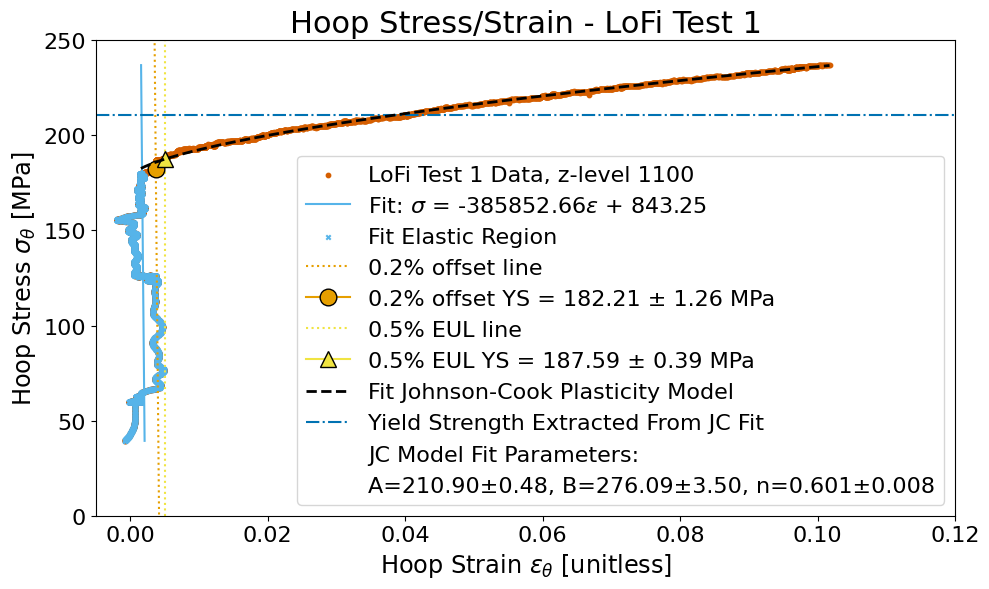

In [14]:
# RUN CELL---execute fits and plotting
test = 1
z_level = 1100
datacontainer_deformationdata_test1 = generatedeformationdata_specific_zlevel(
    datacontainers, 
    target_zlevel_pixels=z_level, 
    test_number=test
)
smoothdeformationdata(datacontainer_deformationdata_test1)
plotdeformationdata_specific(datacontainer_deformationdata_test1, datacontainers, test_number=test, target_zlevel_pixels=z_level)

### Yield Strength vs Z-level

In [25]:
# new data
z_level1 = [750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400]
z_level1_cm = [19.053347514450866, 20.523513217726396, 21.993678921001926, 23.463844624277456, 24.934010327552986, 26.404176030828516, 27.874341734104046, 29.344507437379573, 30.814673140655106, 32.28483884393063, 33.75500454720616, 35.22517025048169, 36.69533595375722, 38.16550165703275]
offset1 = [190.75,191.06,185.57,180.29,181.06,184.56,183.79,182.21,179.81,179.34,179.53,180.82,185.24,185.69]  # MPa
offset_err1 = [2.27,44.83,0.69,0.33,2.18,1.98,12.41,1.26,0.23,9.30,9.81,4.80,3.79,0.49]  # MPa
EUL1 = [194.83,194.68,193.77,195.78,190.57,190.57,192.27,187.59,184.93,188.51,180.77,183.57,190.44,192.75]  # MPa
EUL_err1 = [0.24,0.25,0.37,0.24,0.30,0.35,0.28,0.39,0.30,0.27,0.17,0.20,0.23,0.20]  # MPa
JC1 = [216.38,215.25,217.96,219.16,213.95,214.16,214.62,210.90,205.93,203.56,188.64,200.12,211.76,204.97]  # MPa
JC_err1 = [0.01,0.02,0.01,0.002,0.07,0.10,0.04,0.48,0.34,0.48,0.48,0.36,0.46,0.72]  # MPa

In [26]:
# new data
z_level2 = [850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1350, 1400]
z_level2_cm = [20.448828799999998, 22.14441991111111, 23.840011022222225, 25.53560213333333, 27.231193244444444, 28.926784355555558, 30.622375466666664, 32.31796657777778, 37.40473991111111, 39.10033102222222]
offset2 = [190.16,191.43,189.42,187.88,183.40,183.89,188.78,187.27,165.02,174.69]  # MPa
offset_err2 = [1.82,1.03,0.07,0.17,24.67,9.68,0.73,0.06,0.82,1.15]  # MPa
EUL2 = [190.79,196.02,193.56,192.06,186.46,186.26,189.74,187.03,135.05,70.01]  # MPa
EUL_err2 = [0.33,0.49,0.41,0.25,0.30,0.27,0.30,0.24,0.22,0.12]  # MPa
JC2 = [216.94,221.13,218.85,217.33,215.81,217.23,216.01,215.88,190.26,20.00]  # MPa
JC_err2 = [0.01,0.02,0.02,0.01,0.02,0.01,0.02,0.02,0.3,18.59]  # MPa

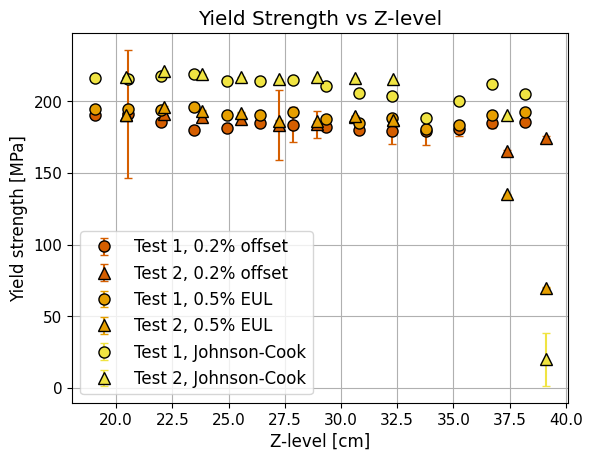

In [43]:
# plotting
z_level_cm_r2 = [round(item, 2) for item in z_level1_cm]
z_level_cm2_r2 = [round(item, 2) for item in z_level2_cm]

z_level_r2 = [round(item, 2) for item in z_level1]
z_level2_r2 = [round(item, 2) for item in z_level2]

fig, ax = plt.subplots()
# 0.2% offset
ax.errorbar(z_level_cm_r2, offset1, yerr=offset_err1, fmt='o', label='Test 1, 0.2% offset', color='#D55E00', markersize=8, markeredgecolor='black', elinewidth=1.5, capsize=3)
ax.errorbar(z_level_cm2_r2, offset2, yerr=offset_err2, fmt='^', label='Test 2, 0.2% offset', color='#D55E00', markersize=8, markeredgecolor='black', elinewidth=1.5, capsize=3)

# 0.5% EUL
ax.errorbar(z_level_cm_r2, EUL1, yerr=EUL_err1, fmt='o', label='Test 1, 0.5% EUL', color='#E69F00', markersize=8, markeredgecolor='black', elinewidth=1.5, capsize=3)
ax.errorbar(z_level_cm2_r2, EUL2, yerr=EUL_err2, fmt='^', label='Test 2, 0.5% EUL', color='#E69F00', markersize=8, markeredgecolor='black', elinewidth=1.5, capsize=3)

# JC
ax.errorbar(z_level_cm_r2, JC1, yerr=JC_err1, fmt='o', label='Test 1, Johnson-Cook', color='#F0E442', markersize=8, markeredgecolor='black', elinewidth=1.5, capsize=3)
ax.errorbar(z_level_cm2_r2, JC2, yerr=JC_err2, fmt='^', label='Test 2, Johnson-Cook', color='#F0E442', markersize=8, markeredgecolor='black', elinewidth=1.5, capsize=3)

ax.set_xlabel('Z-level [cm]', size='large')
ax.set_ylabel('Yield strength [MPa]', size='large')
ax.set_title('Yield Strength vs Z-level', size='x-large')
ax.legend(loc='lower left', fontsize='large')
ax.tick_params(axis='both', labelsize=11)
ax.grid(True)

#plt.savefig("figs/TEST2_ys_vs_z_autumn.pdf", dpi=300)
plt.show()